# 8-parameter Zhao+Plummer: what do proper motions buy?

With proper motions on, `RandomProjection` keeps the two sky-plane
velocity components alongside the line-of-sight one, so each star
contributes $(x, y, v_{\rm los}, v_x, v_y)$ instead of
$(x, y, v_{\rm los})$, and the config attaches an independent
uncertainty model to each velocity channel.

**No single clean comparison exists among the trained runs**, so this
notebook uses three models and brackets the answer between two
imperfect contrasts.

| | obs | prior | epochs | optimizer steps | run |
|---|---|---|---|---|---|
| LOS, prior-matched | 3 | **A** | 8 | 116,999 | `8p_ZhaoPlumCOM/ybqknysx` |
| LOS, trained | 3 | **B** | 40 | 536,120 | `8p_ZhaoPlumCOM_v3/f2wmrbwr` |
| PM | 7 | **A** | 93 | 1,265,626 | `8p_ZhaoPlumCOM_5d/p5zh7bq2` |

* **PM vs LOS prior-matched** shares the prior, the dataset and the
  units, so it isolates proper motions cleanly -- but the LOS model saw
  10.8x fewer optimizer steps, so it overstates the gain.
* **PM vs LOS trained** is within 2.4x on steps, so it understates that
  bias -- but it crosses prior schemes, handled below.

The truth is bracketed by the two. If they agree, the answer is robust.

## The unit problem, and how it is fixed

Prior A stores `dm_log_rdm` as $\log_{10}(r_{\rm dm}/{\rm kpc})$ over
$[-2, 2]$. Prior B stores it as $\log_{10}(r_{\rm dm}/r_\star)$ over
$[0, 3]$. Since $r_\star$ in kpc is a *conditioning input* and therefore
known exactly per galaxy, the conversion is an exact additive shift of
every posterior draw,

$$\log_{10}(r_{\rm dm}/{\rm kpc}) = \log_{10}(r_{\rm dm}/r_\star)
  + \log_{10}(r_\star/{\rm kpc}),$$

which preserves the posterior width exactly. Every other label already
means the same thing under both schemes -- including `df_log_ra`, which
is in units of $r_\star$ either way.

**What the conversion does not fix** is that the two priors are still
different *distributions* on $\log r_{\rm dm}$: uniform on $[-2,2]$ under
A, versus a trapezoid on $[-2,3]$ under B (a sum of two uniforms). So
for `dm_log_rdm` only, compare the **absolute** width in dex, never the
width-over-prior-range column. The other six labels share a prior and
are safe to compare either way.

Each model is evaluated on its **own** dataset's held-out shard 20, so
the comparison is unpaired -- a model is only calibrated on its own
prior, and cannot be tested on the other's galaxies.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '/home/tvnguyen/projects/sbi_dsph/sbi_dsph_pipeline/npe')

import eval_utils as ev

ev.use_style()

N_TEST = 2000
N_SAMPLES = 1000

OUTDIR = os.environ.get(
    'EVAL_OUTDIR', f'/scratch/{os.environ["USER"]}/npe_eval/8p_pm_vs_nopm')
os.makedirs(OUTDIR, exist_ok=True)
print(f'output -> {OUTDIR}')

output -> /scratch/tvnguyen/npe_eval/8p_pm_vs_nopm


## 1. Load the three models

In [2]:
runs = {}

m, c, nd = ev.load_npe_wandb('sbi_dsph/8p_ZhaoPlumCOM/ybqknysx', 'best')
runs['LOS prior-A (undertrained)'] = (m, c, nd, False)

m, c, nd = ev.load_npe(ev.find_run_dir('8p_ZhaoPlumCOM_v3'), 'last.ckpt')
runs['LOS prior-B (trained)'] = (m, c, nd, True)   # needs kpc conversion

m, c, nd = ev.load_npe(ev.find_run_dir('8p_ZhaoPlumCOM_5d'), 'last.ckpt')
runs['PM prior-A (trained)'] = (m, c, nd, False)

names = list(runs['PM prior-A (trained)'][1].labels)
for tag, (m, c, nd, conv) in runs.items():
    print(f'{tag:28s} data={c.data_name:18s} in={c.model.input_size} '
          f'pm={c.pre_transforms.projection_args.get("use_proper_motions", False)}'
          f' convert={conv}')
    assert tuple(c.labels) == tuple(names), 'label sets differ'

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/tvnguyen/.netrc.
wandb:   1 of 1 files downloaded.  


Downloaded checkpoint to: /scratch/tvnguyen/cache/wandb_artifacts/artifacts/model-ybqknysx:v8/model.ckpt
fetched sbi_dsph/8p_ZhaoPlumCOM/ybqknysx (best)
loaded model.ckpt (epoch 6)
[NPE] Flows built from scratch with 328,134 parameters
loaded last.ckpt (epoch 74)
[NPE] Flows built from scratch with 328,134 parameters
loaded last.ckpt (epoch 92)
[NPE] Flows built from scratch with 328,134 parameters
LOS prior-A (undertrained)   data=8p_ZhaoPlumCOM     in=3 pm=False convert=False
LOS prior-B (trained)        data=8p_ZhaoPlumCOM_v3  in=3 pm=False convert=True
PM prior-A (trained)         data=8p_ZhaoPlumCOM     in=7 pm=True convert=False


## 2. Sample each on its own held-out shard, in common units

In [3]:
post = {}
for tag, (model, cfg, nd, conv) in runs.items():
    loader, shard = ev.load_test_set(cfg, nd, max_graphs=N_TEST)
    s, t = ev.sample_posterior(model, loader, num_samples=N_SAMPLES)
    if conv:
        cond = ev.extract_cond(loader, nd)
        s, t = ev.priorb_rdm_to_kpc(
            s, t, cond, names, list(cfg.cond_labels))
    post[tag] = (s, t)
    i = names.index('dm_log_rdm')
    print(f'{tag:28s} shard {shard}  n={t.shape[0]}  '
          f'log_rdm[kpc] in [{t[:, i].min():.2f}, {t[:, i].max():.2f}]')

100%|██████████| 1/1 [00:05<00:00,  5.21s/it]
Seed set to 0


test shard data.20.h5: 100000 galaxies (training read shards 0-19)


100%|██████████| 16/16 [00:10<00:00,  1.60it/s]


LOS prior-A (undertrained)   shard 20  n=2000  log_rdm[kpc] in [-2.00, 2.00]


100%|██████████| 1/1 [00:01<00:00,  1.27s/it]
Seed set to 0


...

LOS prior-B (trained)        shard 20  n=2000  log_rdm[kpc] in [-1.98, 2.90]


100%|██████████| 1/1 [00:00<00:00, 10.56it/s]
Seed set to 0


test shard data.20.h5: 100000 galaxies (training read shards 0-19)


100%|██████████| 16/16 [00:11<00:00,  1.40it/s]


PM prior-A (trained)         shard 20  n=2000  log_rdm[kpc] in [-2.00, 2.00]


All three now report `dm_log_rdm` in kpc. The prior-B range is wider by
construction, which is exactly why only its absolute width is
comparable.

## 3. Example corner plot per model

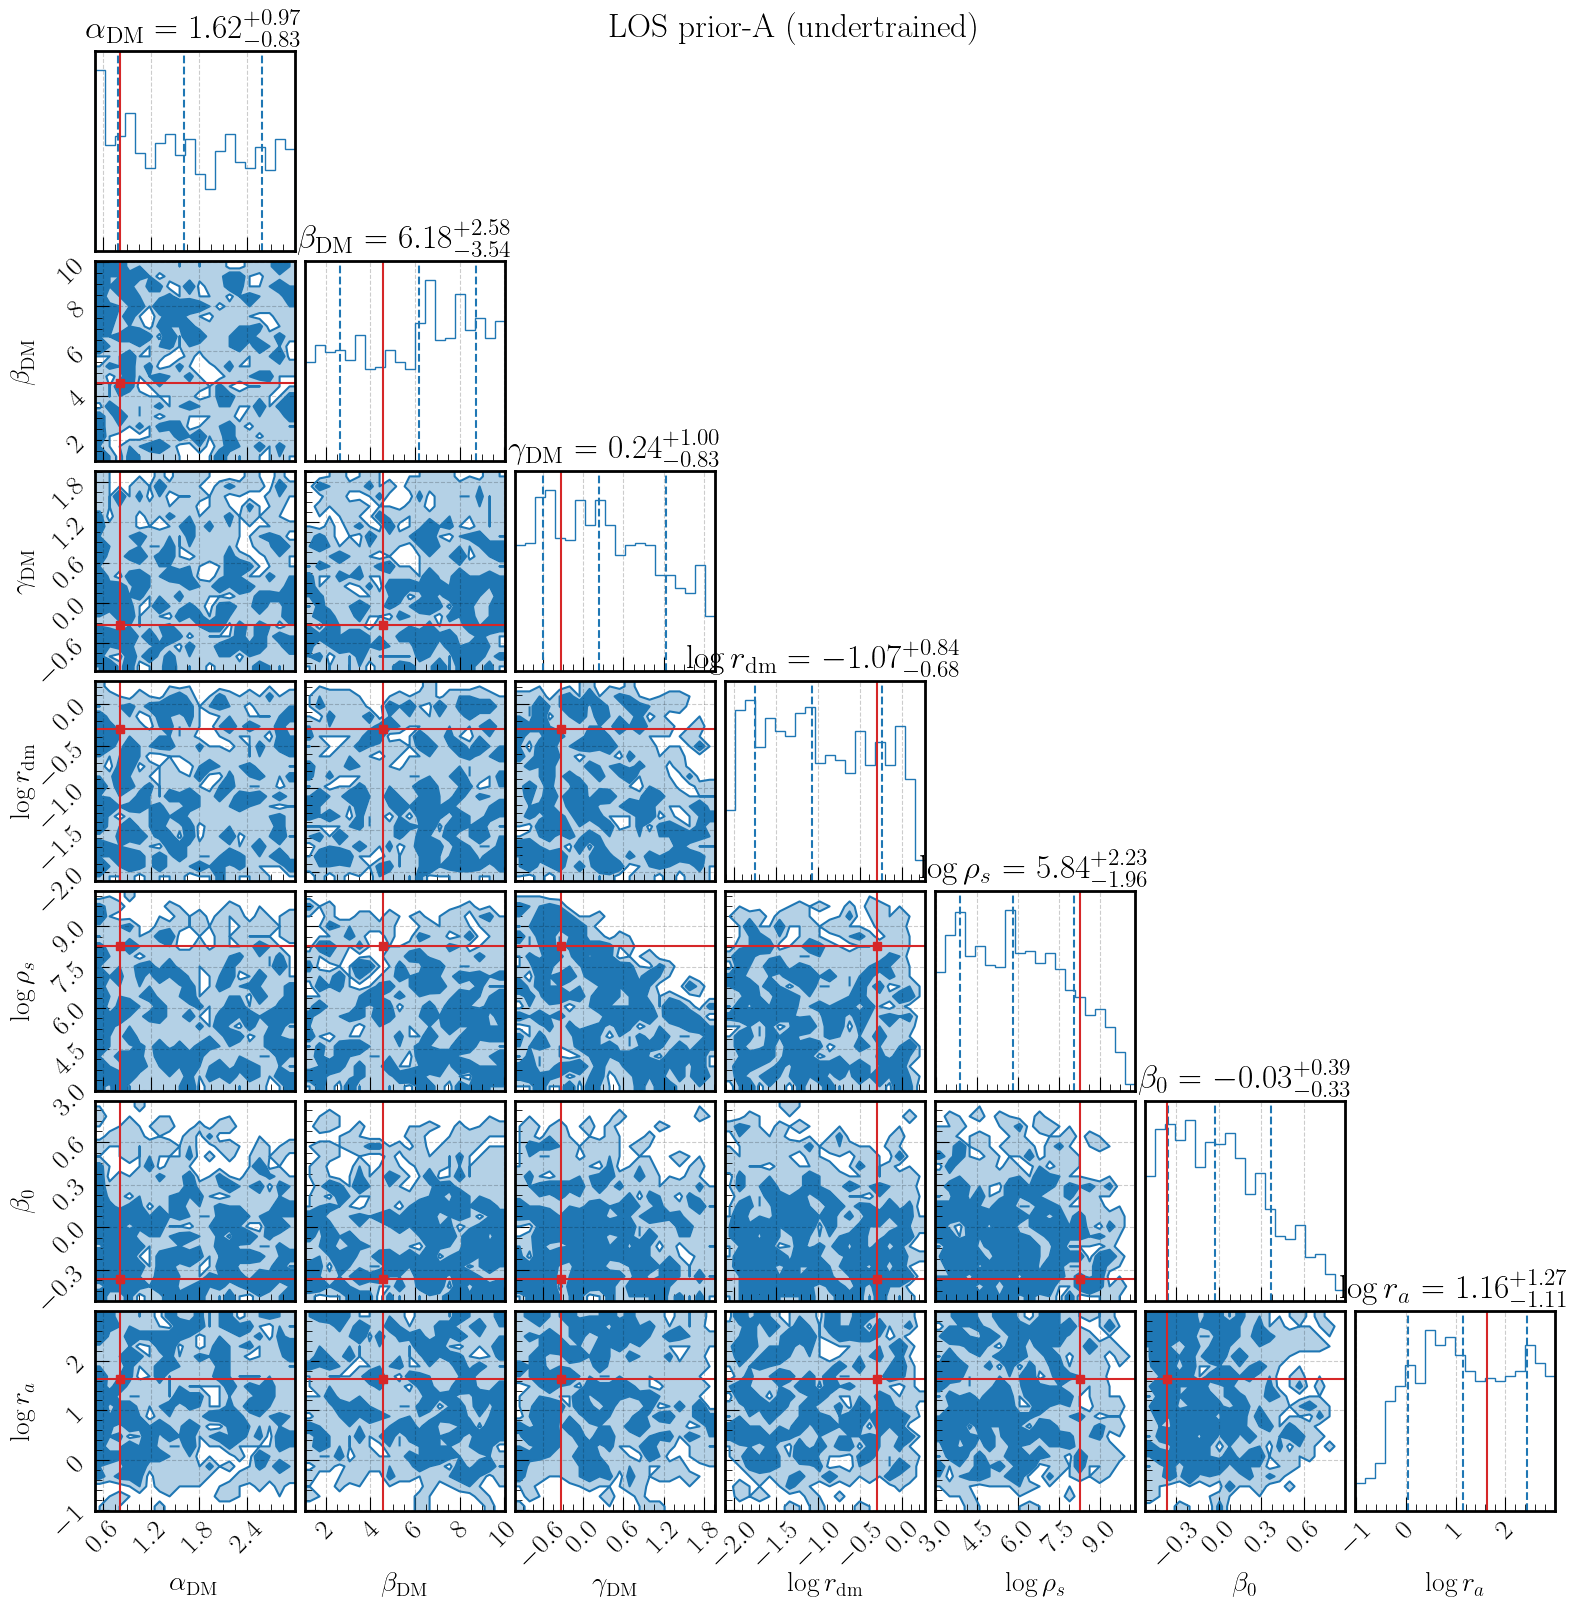

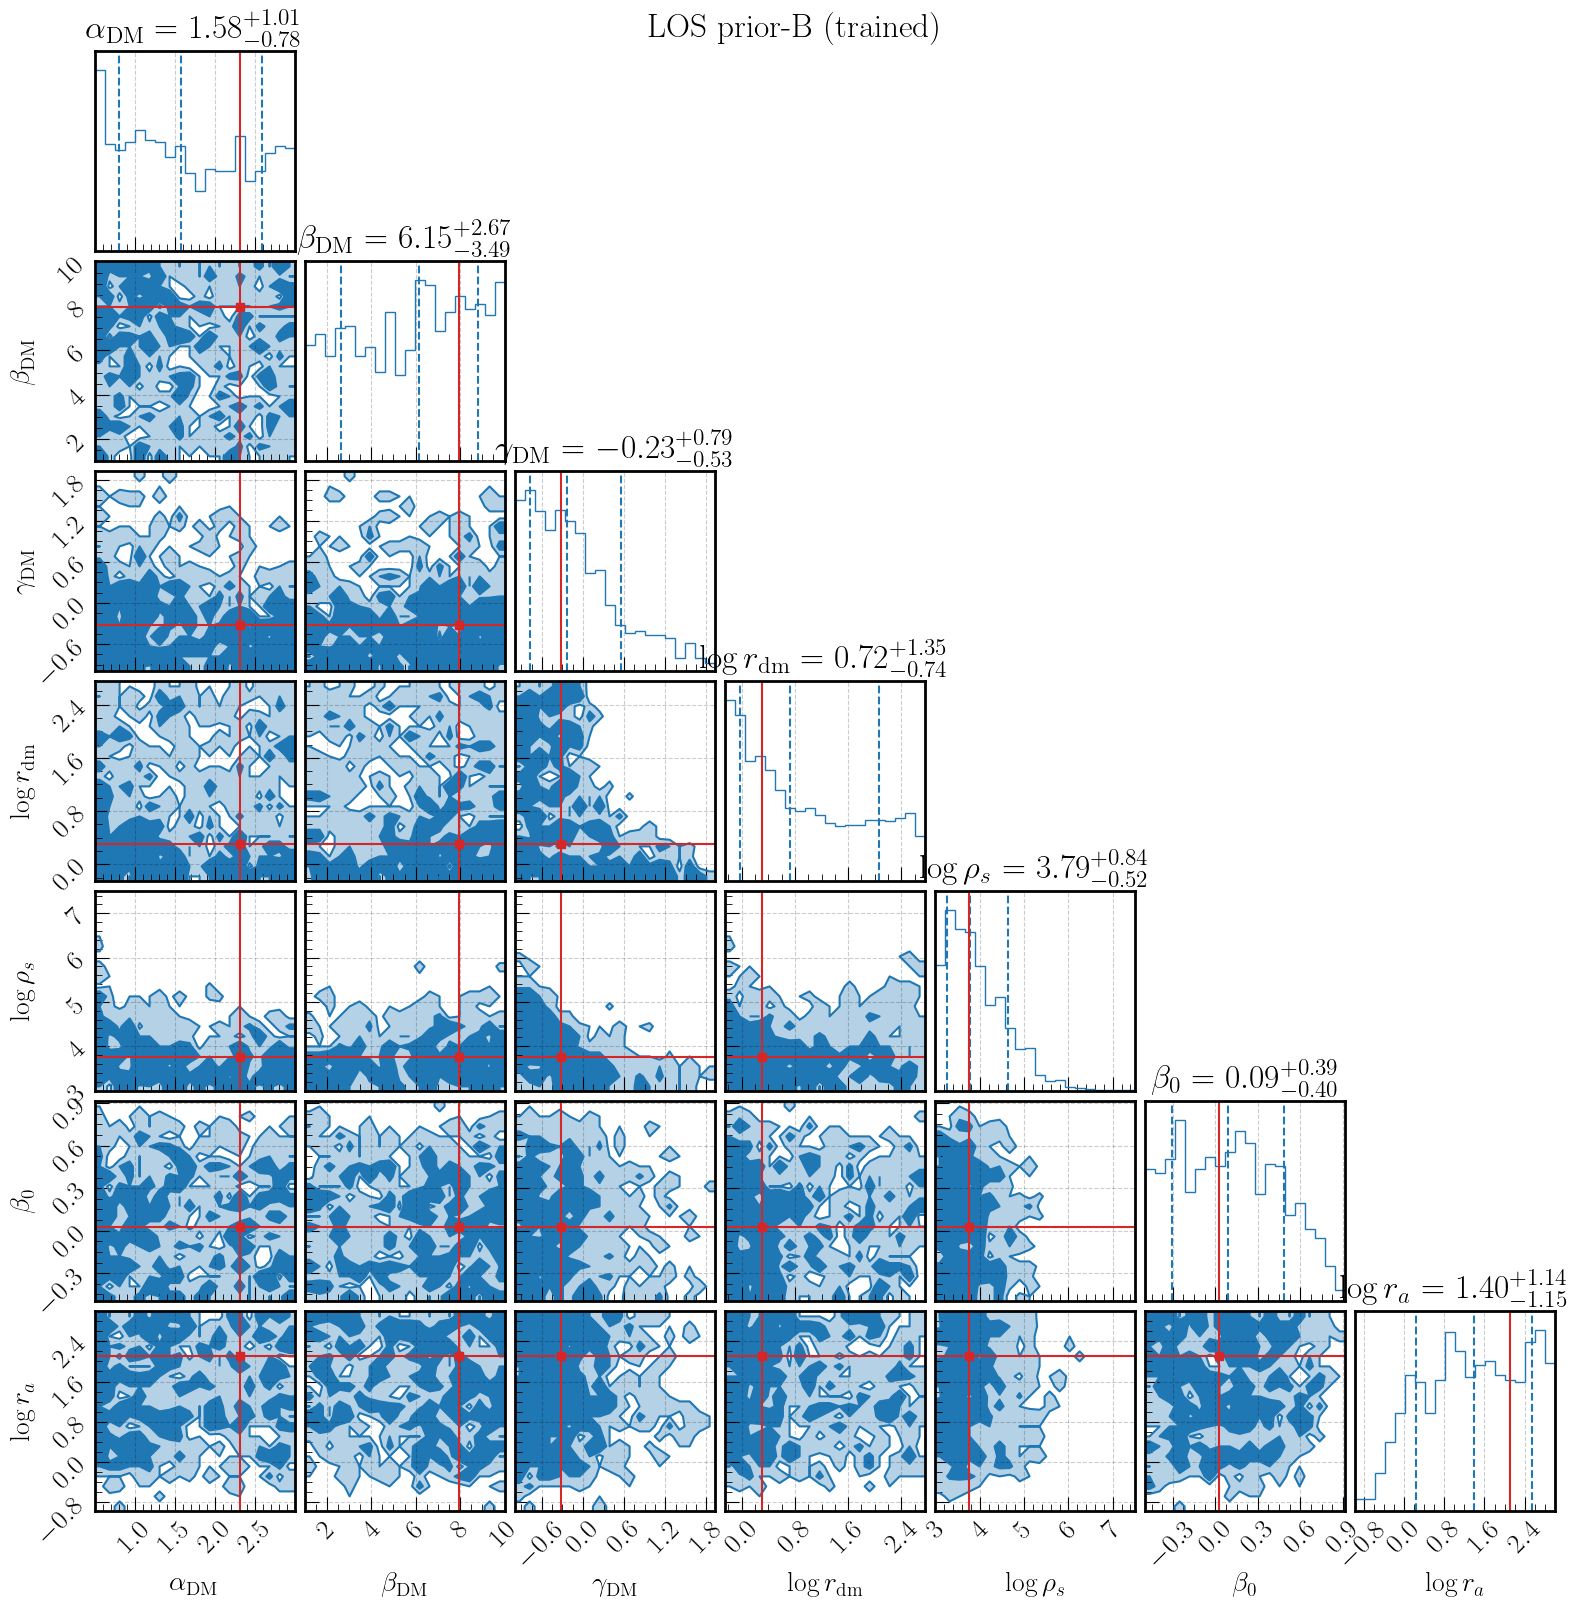

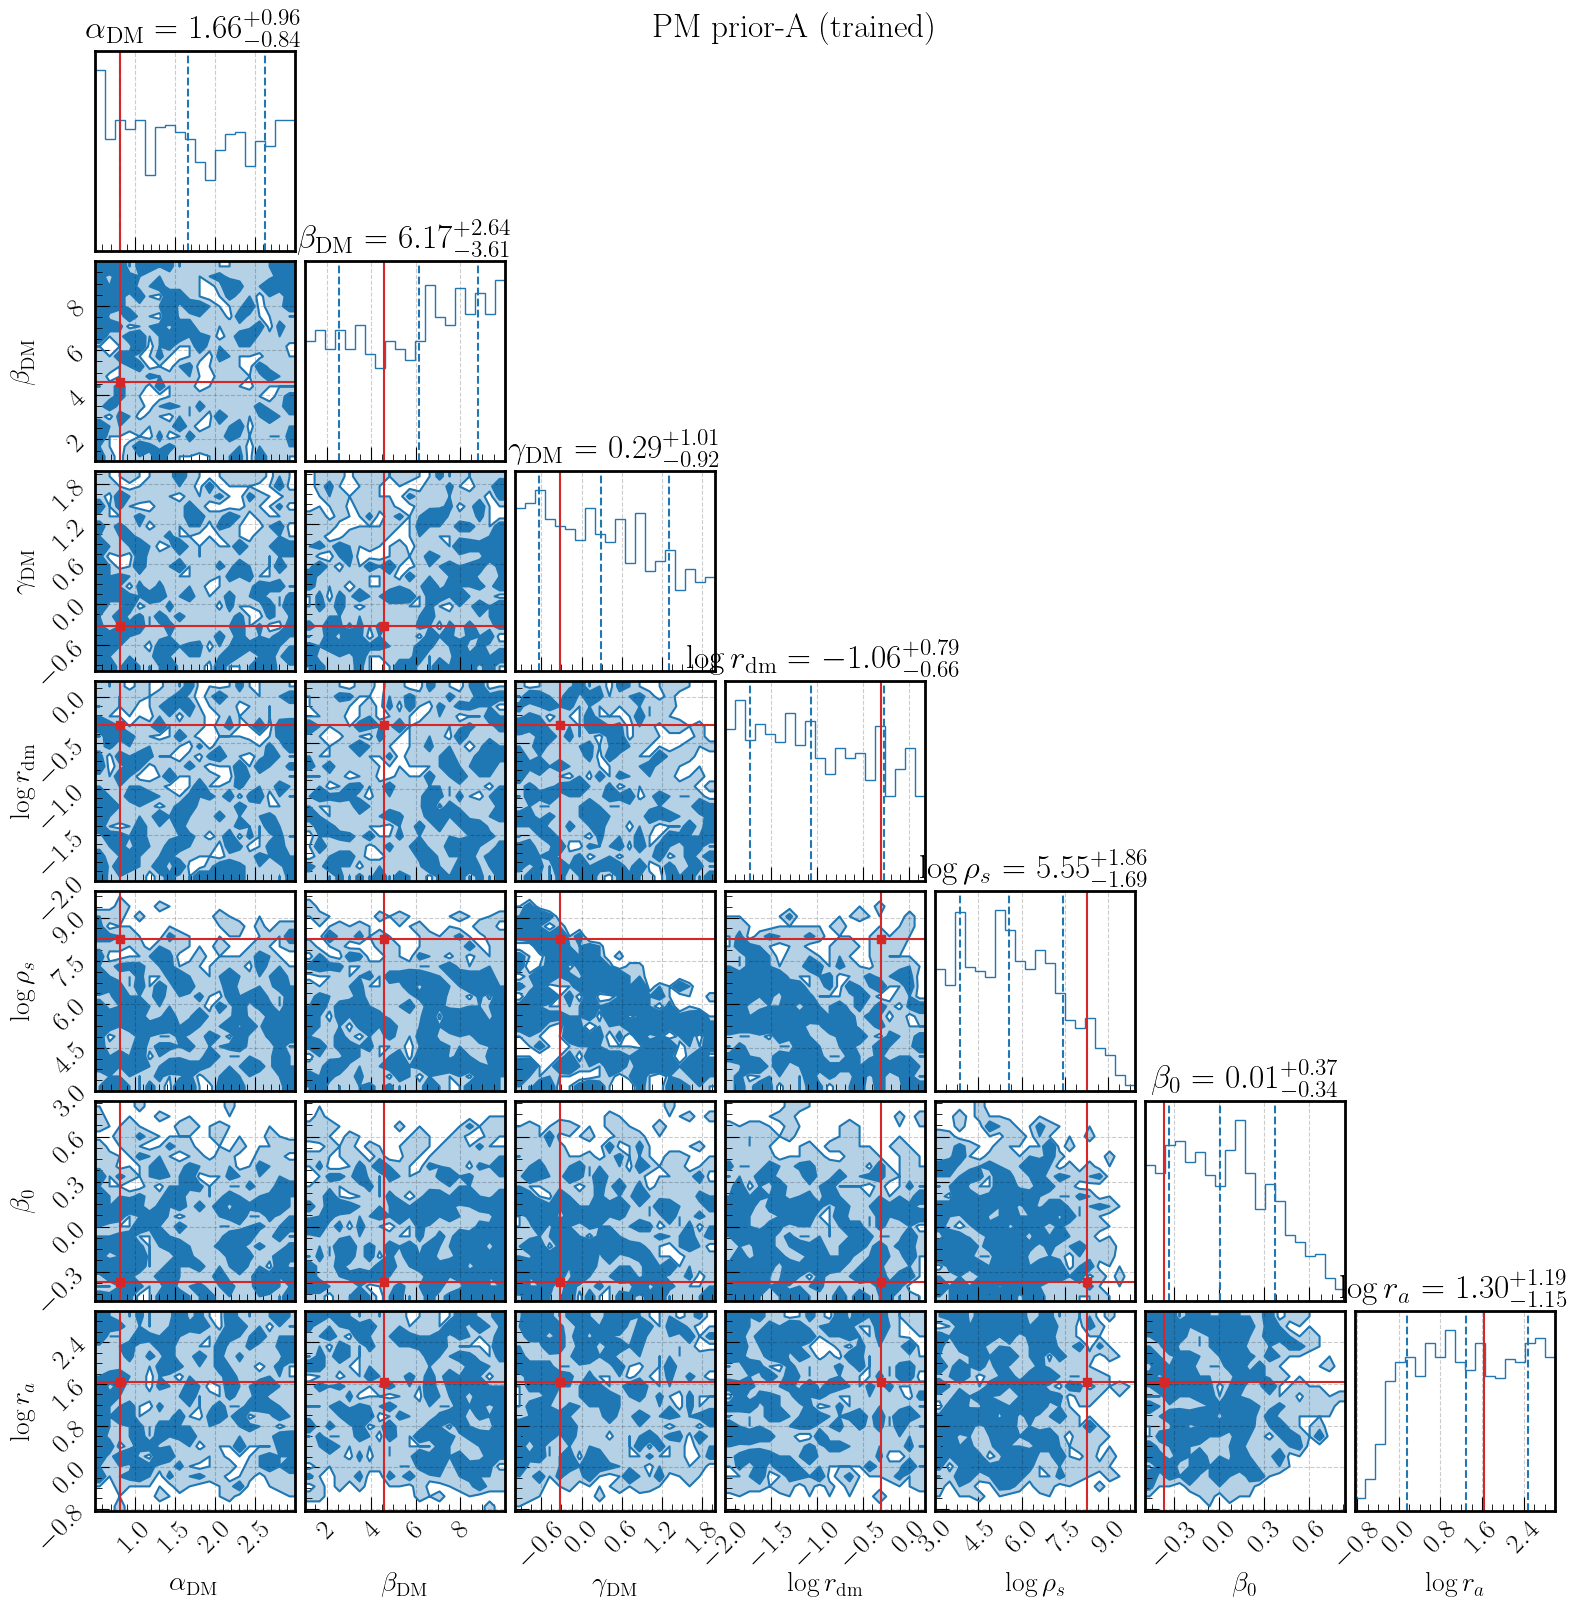

In [4]:
for tag, (s, t) in post.items():
    key = tag.split()[0].lower() + ('_b' if 'B' in tag else '_a')
    fig = ev.plot_corner(s, t, names, index=0,
                         out_path=f'{OUTDIR}/fig1_corner_{key}.png')
    fig.suptitle(tag, y=1.0)
    plt.show()

## 4. Median vs truth

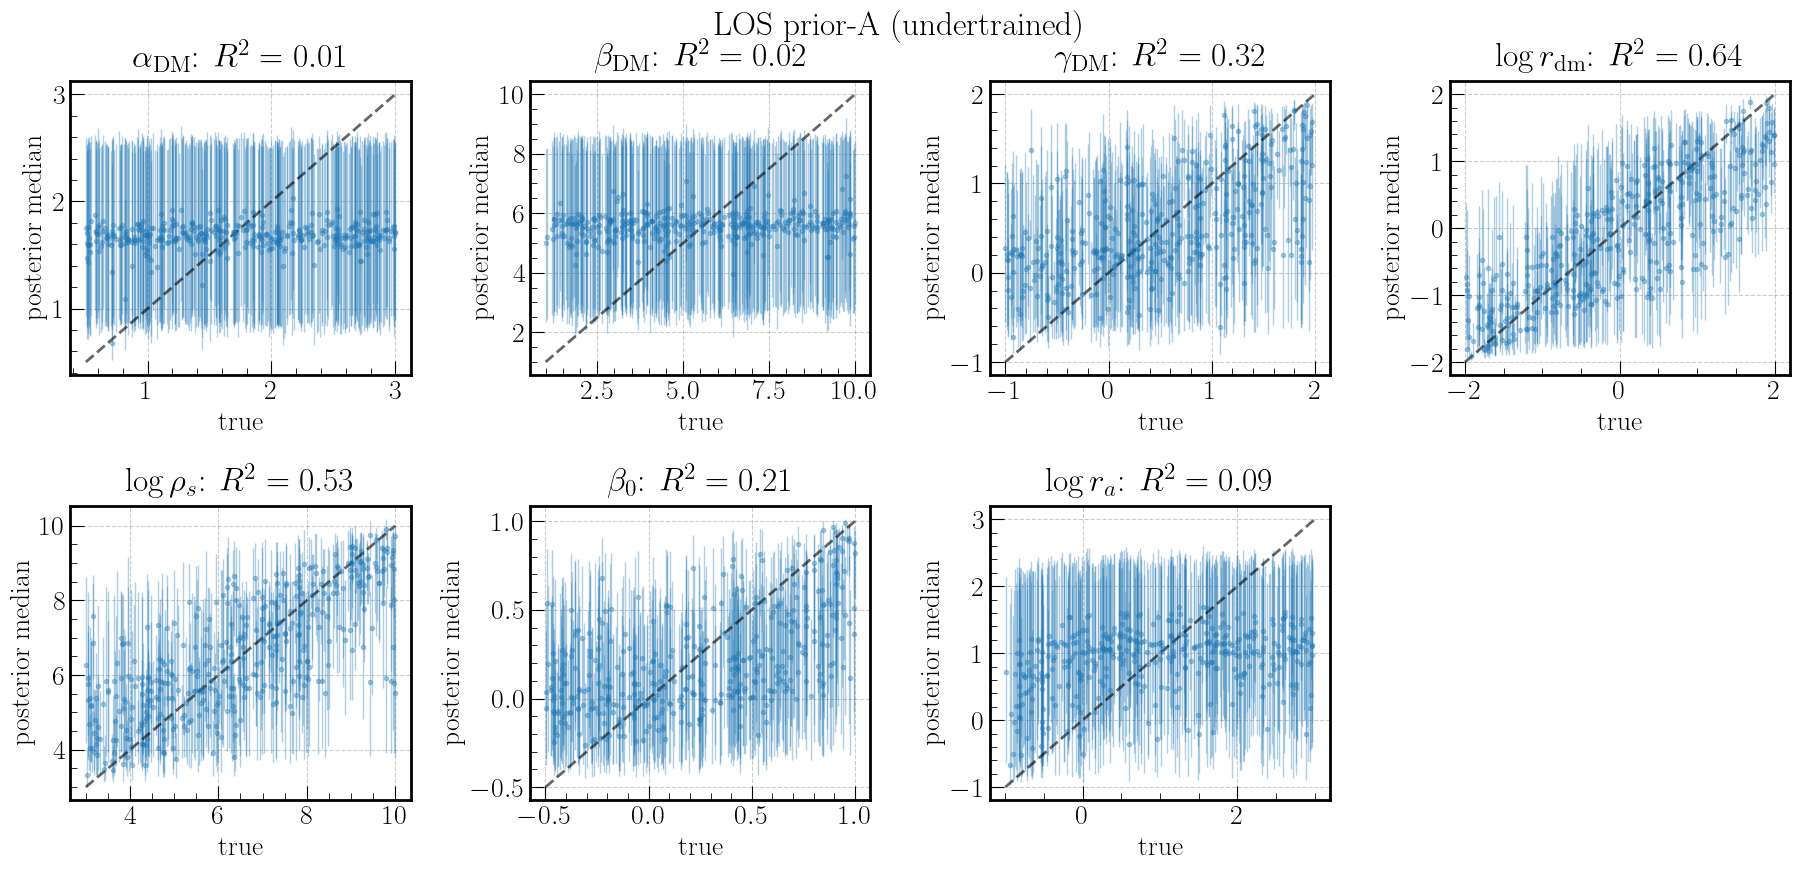

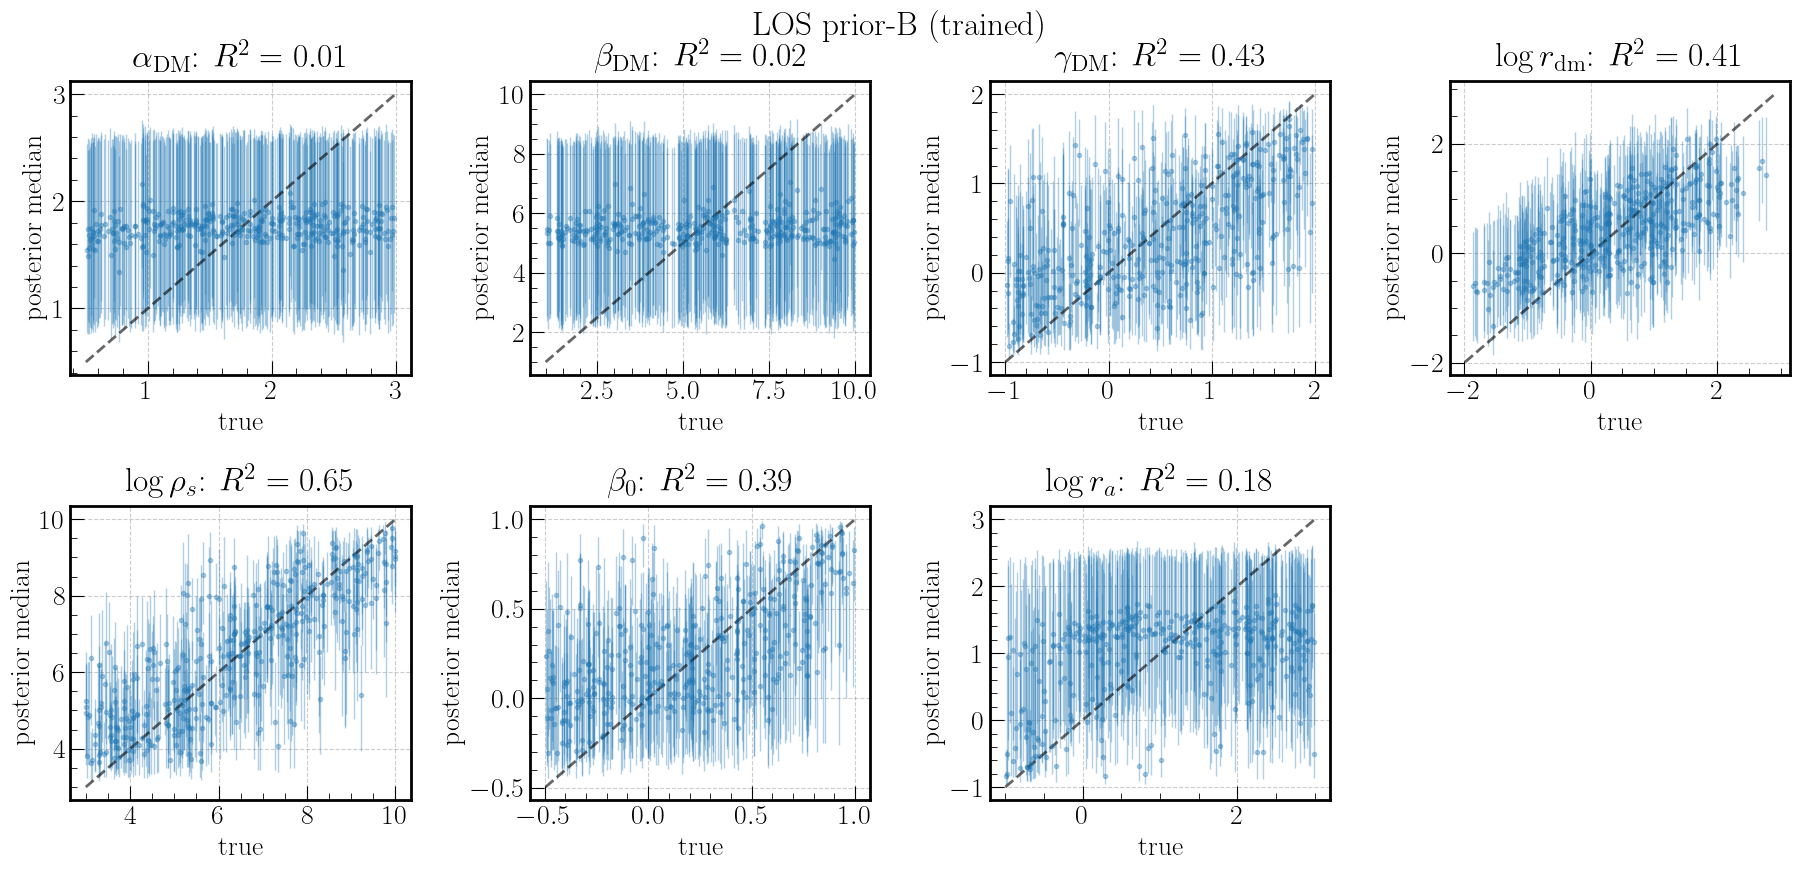

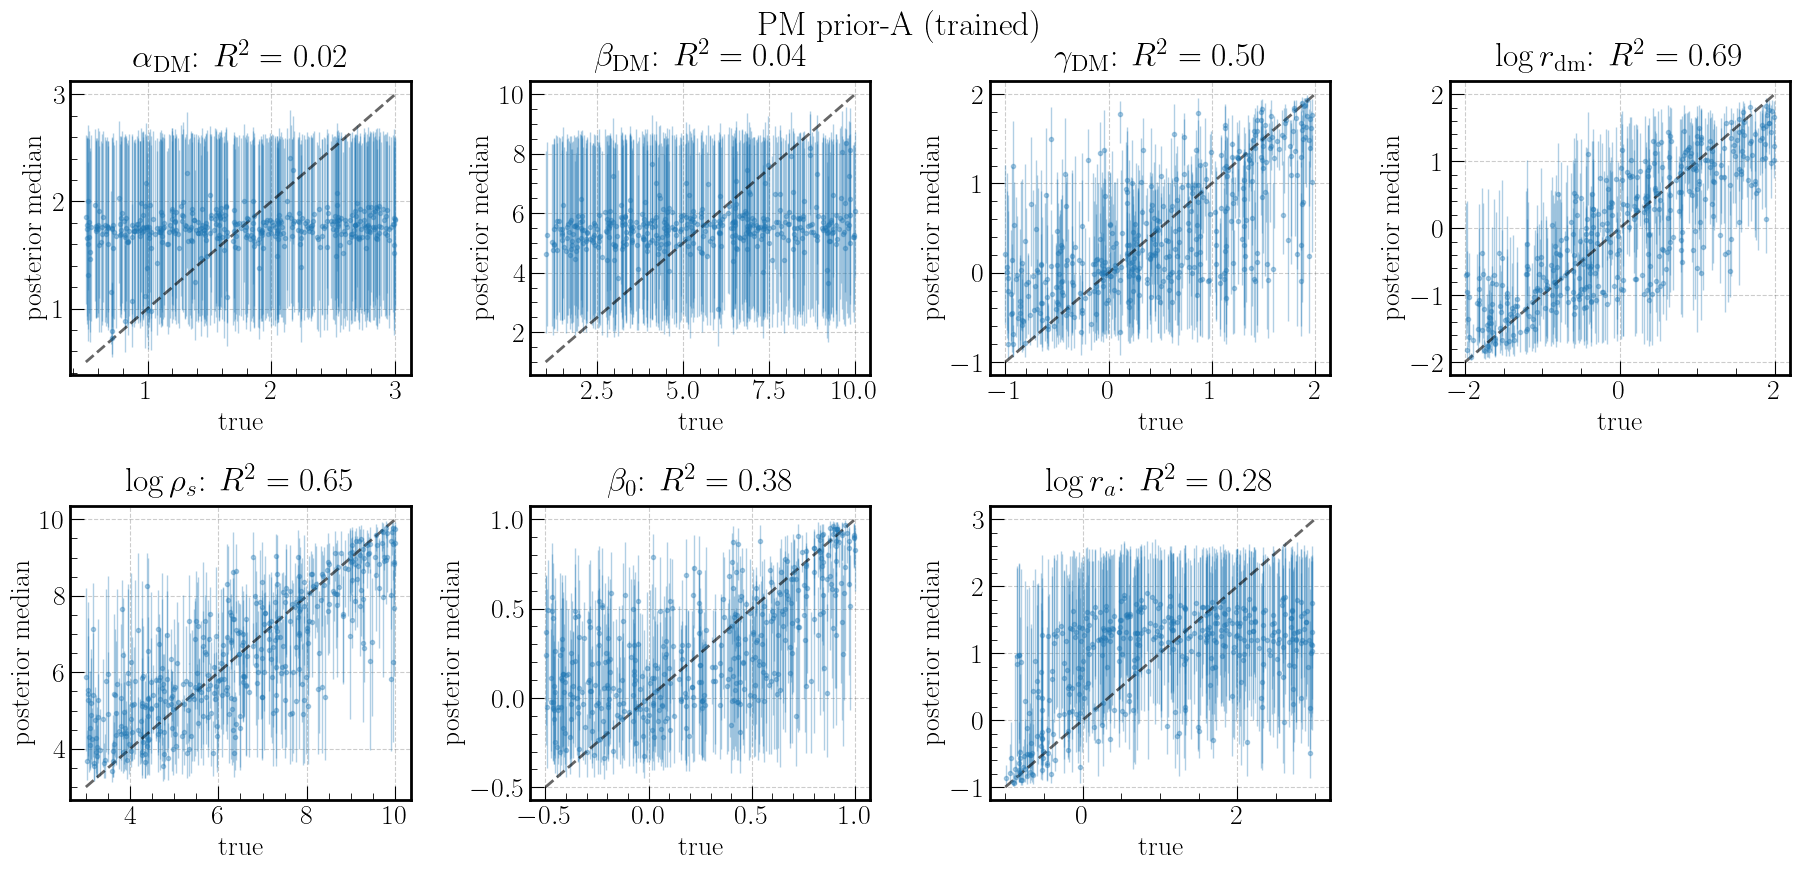

In [5]:
stats = {}
for tag, (s, t) in post.items():
    key = tag.split()[0].lower() + ('_b' if 'B' in tag else '_a')
    fig, st = ev.plot_pred_vs_true(
        s, t, names, out_path=f'{OUTDIR}/fig2_pvt_{key}.png')
    fig.suptitle(tag, y=1.0)
    plt.show()
    stats[tag] = st

## 5. The two contrasts

Remember: for `dm_log_rdm` read the **absolute** width column; for the
other six the width-over-prior column is also valid.

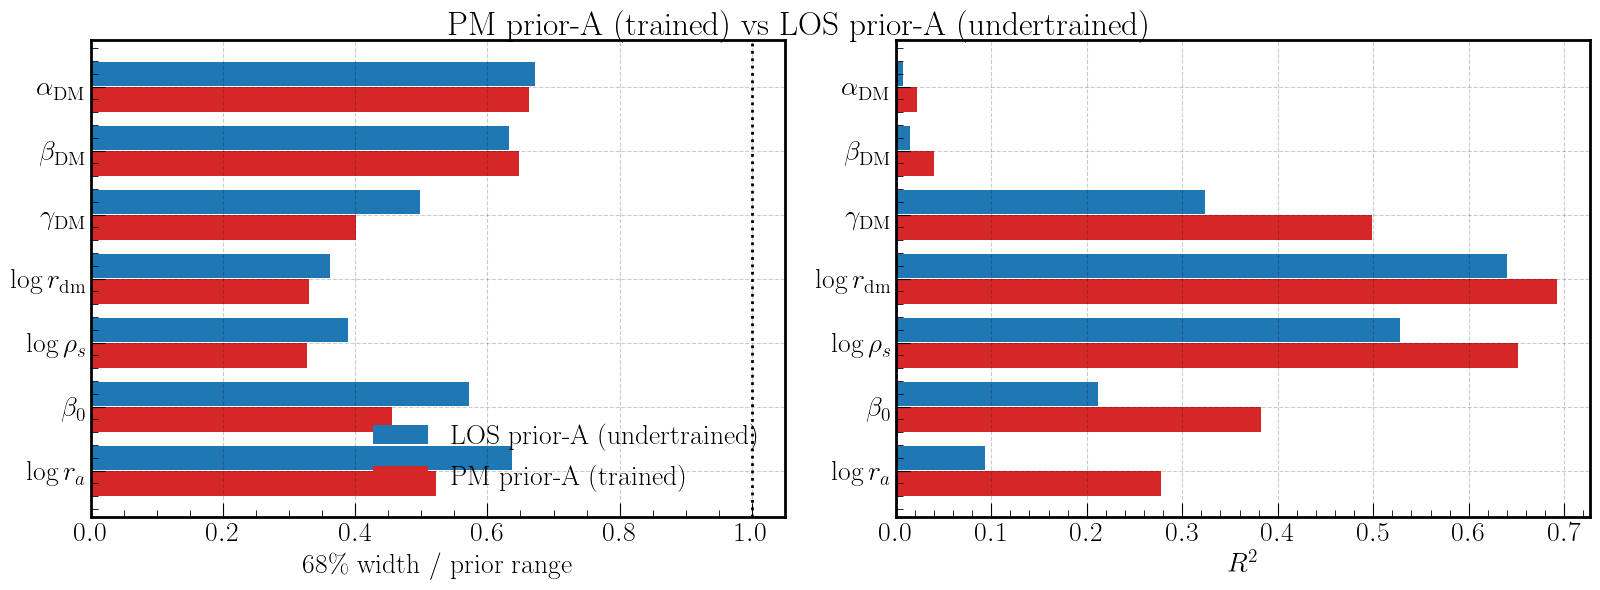

=== PM vs LOS prior-A (undertrained)
parameter          w68 LOS   w68 PM  abs ratio   R2 LOS   R2 PM
dm_alpha             1.679    1.654       0.99    0.008   0.023
dm_beta              5.687    5.818       1.02    0.015   0.040
dm_gamma             1.492    1.204       0.81    0.324   0.499
dm_log_rdm           1.447    1.318       0.91    0.640   0.692
dm_log_rho0          2.720    2.283       0.84    0.528   0.652
df_beta0             0.858    0.683       0.80    0.211   0.383
df_log_ra            2.547    2.087       0.82    0.093   0.277



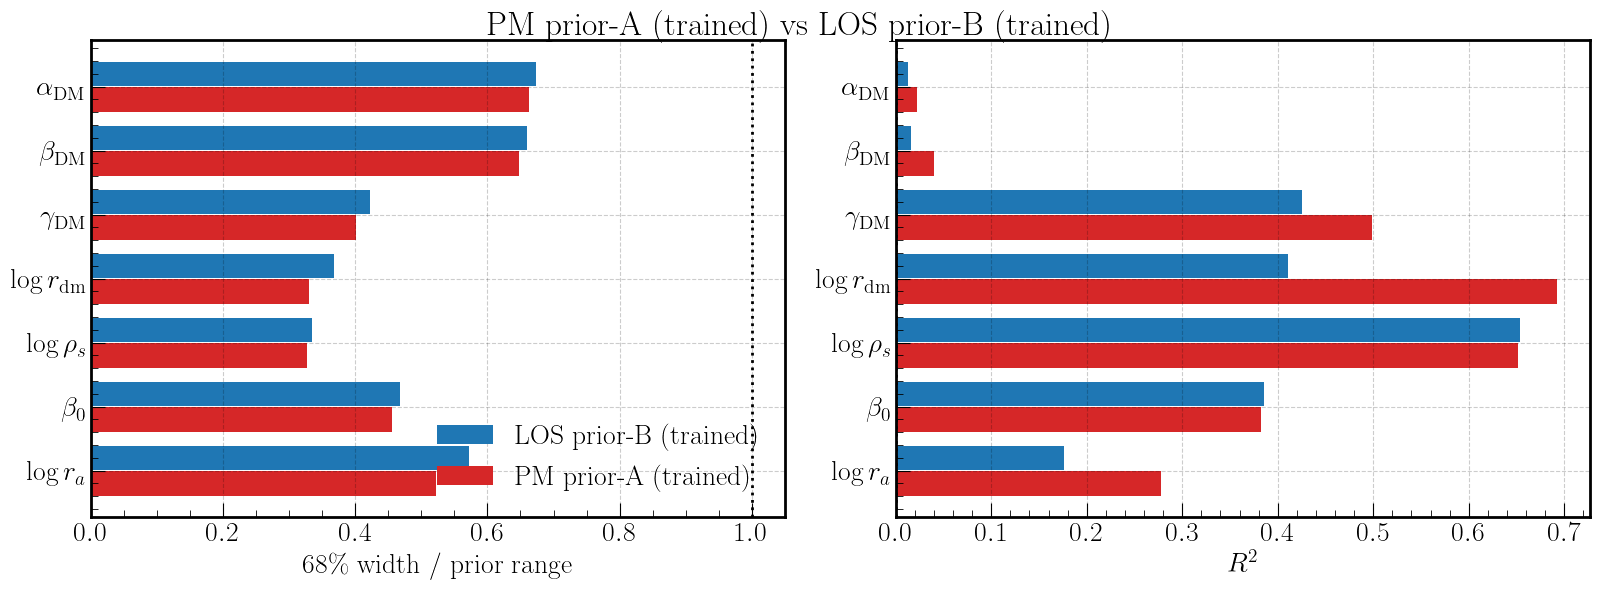

=== PM vs LOS prior-B (trained)
parameter          w68 LOS   w68 PM  abs ratio   R2 LOS   R2 PM
dm_alpha             1.682    1.654       0.98    0.012   0.023
dm_beta              5.926    5.818       0.98    0.016   0.040
dm_gamma             1.265    1.204       0.95    0.425   0.499
dm_log_rdm           1.801    1.318       0.73    0.411   0.692  <- abs only
dm_log_rho0          2.341    2.283       0.98    0.653   0.652
df_beta0             0.700    0.683       0.98    0.385   0.383
df_log_ra            2.287    2.087       0.91    0.176   0.277



: 

In [ ]:
PM = 'PM prior-A (trained)'
for other in ('LOS prior-A (undertrained)', 'LOS prior-B (trained)'):
    fig, ratio = ev.plot_model_comparison(
        stats[other], stats[PM], names, other, PM,
        out_path=f'{OUTDIR}/fig3_vs_{"a" if "A" in other else "b"}.png')
    fig.suptitle(f'{PM}  vs  {other}', y=1.0)
    plt.show()

    print(f'=== PM vs {other}')
    print(f'{"parameter":<16s} {"w68 LOS":>9s} {"w68 PM":>8s} '
          f'{"abs ratio":>10s} {"R2 LOS":>8s} {"R2 PM":>7s}')
    for n in names:
        a, b = stats[other][n], stats[PM][n]
        flag = '  <- abs only' if n == 'dm_log_rdm' and 'B' in other else ''
        print(f'{n:<16s} {a["width68"]:9.3f} {b["width68"]:8.3f} '
              f'{b["width68"] / a["width68"]:10.2f} '
              f'{a["r2"]:8.3f} {b["r2"]:7.3f}{flag}')
    print()

## 6. Calibration of each model

Per-model statements, unaffected by any of the cross-model confounds:
an undertrained model can be perfectly calibrated, just wide.

100%|██████████| 100/100 [00:11<00:00,  8.49it/s]


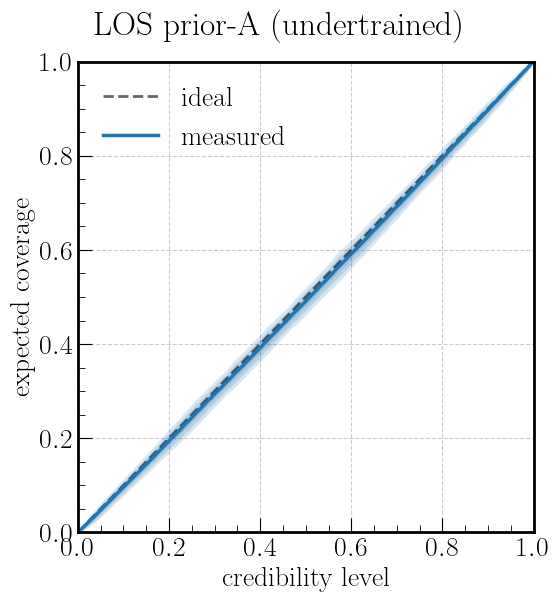

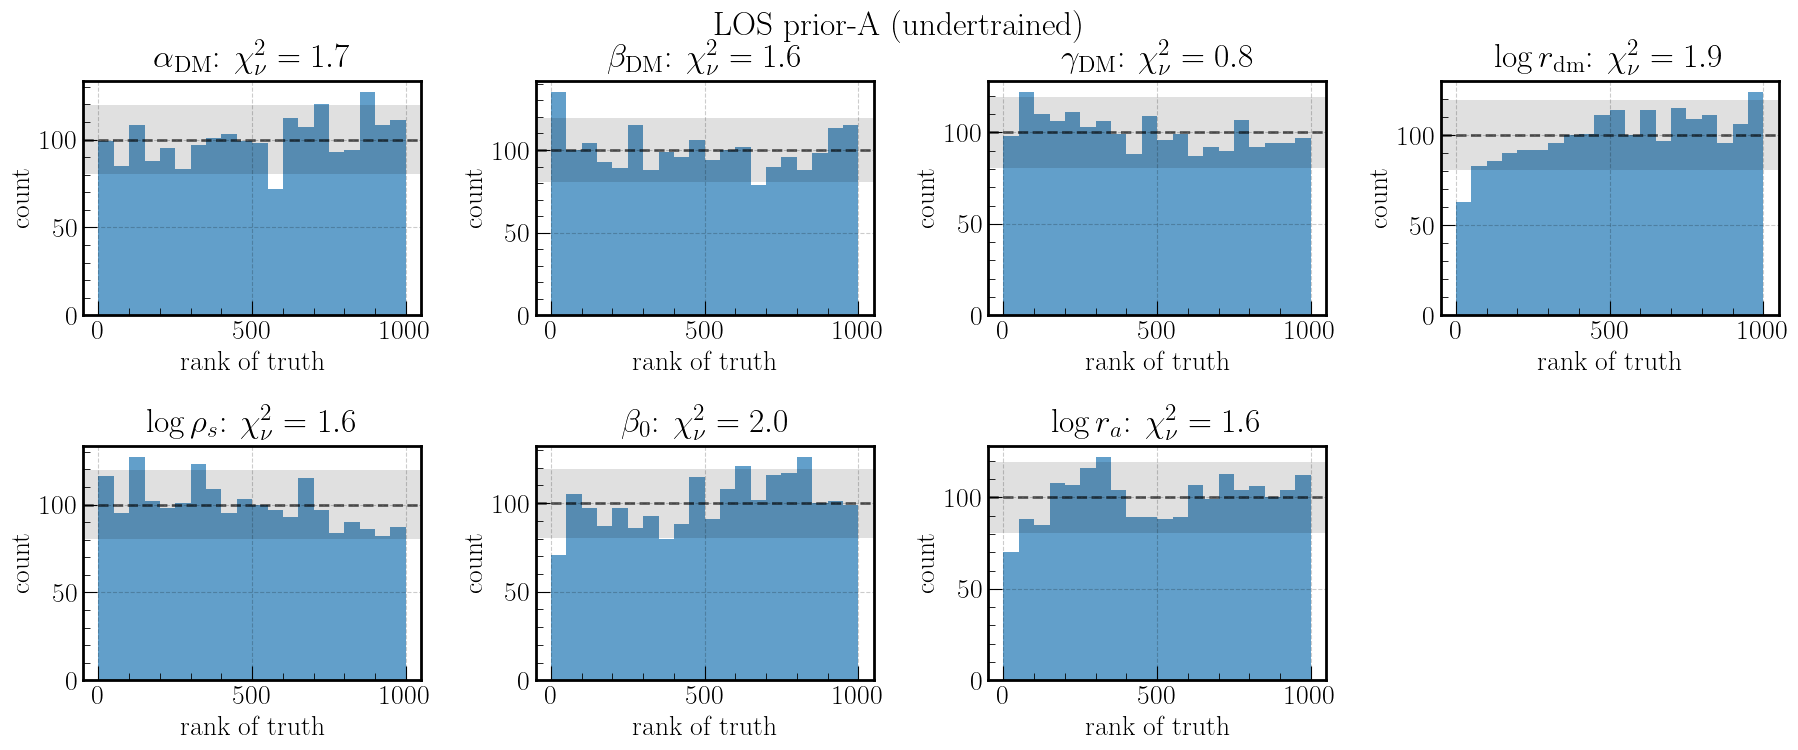

In [ ]:
summary = {}
for tag, (s, t) in post.items():
    key = tag.split()[0].lower() + ('_b' if 'B' in tag else '_a')
    fig, dev = ev.plot_tarp(s, t, out_path=f'{OUTDIR}/fig4_tarp_{key}.png')
    fig.suptitle(tag, y=1.02)
    plt.show()
    fig, chi2 = ev.plot_rank_marginals(
        s, t, names, out_path=f'{OUTDIR}/fig5_rank_{key}.png')
    fig.suptitle(tag, y=1.0)
    plt.show()
    fig, corr = ev.plot_correlation_matrices(
        s, t, names, out_path=f'{OUTDIR}/fig6_corr_{key}.png')
    fig.suptitle(tag, y=1.0)
    plt.show()
    fig, pair = ev.plot_pairwise_rank_calibration(
        s, t, names, out_path=f'{OUTDIR}/fig7_pair_{key}.png')
    fig.suptitle(tag, y=1.0)
    plt.show()
    mira = ev.mira_scores(s, t, num_runs=100)
    summary[tag] = dict(tarp=dev, chi2=chi2, corr=corr, pair=pair, mira=mira)

for tag, d in summary.items():
    print(f'{tag:28s} TARP {d["tarp"]:.4f}  '
          f'worst marginal {max(d["chi2"].values()):.2f}  '
          f'max|offdiag| {d["corr"]["max_offdiag"]:.3f}  '
          f'worst pair {d["pair"]["worst_pair"][2]:.2f}  '
          f'MIRA {d["mira"]["model"][0]:.4f}')

## Summary

In [ ]:
print('mean |68% width| over the six prior-matched labels:')
shared = [n for n in names if n != 'dm_log_rdm']
for tag in post:
    w = np.mean([stats[tag][n]['width68'] for n in shared])
    print(f'  {tag:28s} {w:.3f}')
print()
for other in ('LOS prior-A (undertrained)', 'LOS prior-B (trained)'):
    r = np.mean([stats[PM][n]['width68'] / stats[other][n]['width68']
                 for n in shared])
    print(f'PM / {other:28s} mean width ratio {r:.2f}')
print()
print('Bracket: the prior-matched contrast overstates the proper-motion')
print('gain (10.8x fewer LOS steps); the trained contrast understates the')
print('training bias (2.4x) but crosses priors. A matched pair would need')
print('an LOS model retrained on 8p_ZhaoPlumCOM to ~1.27M steps.')